# Transferarbeit — Utilizzo della rete ferroviaria in Europa

Analisi comparata dell'uso del treno tra paesi europei, misurato tramite due indicatori normalizzati:

- **passenger-km pro capite** — quanto viaggia in treno in media un abitante
- **passenger-km per km di rete** — quanto e' sfruttata l'infrastruttura ferroviaria esistente

Pipeline: acquisizione dati (Eurostat + fallback World Bank/OWID + prezzo carburante come variabile esogena), pulizia e merge, definizione delle variabili derivate, profiling automatico del dataset pulito, modelli predittivi per entrambi i target (con segno dell'effetto di ciascun fattore), clustering dei paesi.

Esclusi dai modelli predittivi (sezione 8): anni 2020-2022 (anomalia Covid-19) — restano pero'
visibili in EDA, profiling e grafici, dove l'anomalia e' segnalata esplicitamente invece di sparire
in silenzio. Esclusi dall'intera analisi: paesi con copertura dati insufficiente o valori anomali
(Ucraina, Liechtenstein, Bosnia ed Erzegovina, Montenegro, Macedonia del Nord, oltre a eventuali
altri sotto una soglia minima di osservazioni valide).

## 1. Setup

In [1]:
%pip install -q openpyxl sweetviz plotly scikit-learn --disable-pip-version-check

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme()
matplotlib.rcParams['figure.figsize'] = [12, 6]
pd.set_option('display.max_columns', 50)

In [13]:
import os

# Cartella di lavoro su Google Drive (i file locali di fallback e il carburante vanno
# messi qui). Se il notebook non gira su Colab, o Drive non e' montato, si resta nella
# working directory corrente senza interrompere l'esecuzione.
WORKING_DIR = "/content/drive/MyDrive/dati_tesi"

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    print("[info] non in esecuzione su Colab: monta Drive manualmente se necessario.")

if os.path.isdir(WORKING_DIR):
    os.chdir(WORKING_DIR)
else:
    print(f"[attenzione] {WORKING_DIR} non trovato, resto nella working directory corrente.")

print("Working directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/dati_tesi


## 2. Sorgenti dati

Fonti primarie: API Eurostat (SDMX 3.0, formato CSV compresso). Fonti di fallback (usate solo per
riempire i buchi lasciati da Eurostat su paesi/anni minori): World Bank (formato wide per anno) e
Our World in Data (OWID) per i passeggeri-km storici.

In [14]:
# URL invariati rispetto allo script originale (gia' testati e funzionanti), tranne
# "area" dove labels=both e' stato cambiato in labels=label_only: rende il confronto sul
# nome paese univoco e permette un match esatto invece del fragile str.contains() originale.
EUROSTAT = {
    "rail_passengers": "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/rail_pa_total/1.0?compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only",
    "rail_length": "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/rail_if_line_na/1.0?compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only",
    "cars_per_capita": "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/road_eqs_carhab/1.0/*.*.*?c[freq]=A&c[unit]=NR&c[geo]=EU27_2020,BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE,IS,LI,NO,CH,UK,BA,ME,MD,MK,GE,AL,RS,TR,UA,XK&c[TIME_PERIOD]=2024,2023,2022,2021,2020,2019,2018,2017,2016,2015,2014,2013,2012,2011,2010,2009,2008,2007,2006,2005,2004,2003,2002,2001,2000,1999,1998,1997,1996,1995,1994,1993,1992,1991,1990&compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only",
    "population": "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/demo_pjan/1.0/*.*.*.*.*?c[freq]=A&c[unit]=NR&c[age]=TOTAL&c[sex]=T&c[geo]=BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,FX,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE,IS,LI,NO,CH,UK,BA,ME,MD,MK,GE,AL,RS,TR,UA,XK,AD,BY,MC,RU,SM,AM,AZ&c[TIME_PERIOD]=2025,2024,2023,2022,2021,2020,2019,2018,2017,2016,2015,2014,2013,2012,2011,2010,2009,2008,2007,2006,2005,2004&compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only",
    "gdp_per_capita": "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/sdg_08_10/1.0/*.*.*.*?c[freq]=A&c[unit]=CLV20_EUR_HAB&c[na_item]=B1GQ&c[geo]=BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE,IS,NO,CH,AL,BA,EA19,ME,MK,RS,TR&c[TIME_PERIOD]=2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025&compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only",
    "area": "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/demo_r_d3area/1.0/*.*.*.*?c[freq]=A&c[unit]=KM2&c[landuse]=TOTAL&c[geo]=BE,BE1,BE10,BE100,BE2,BE21,BE211,BE212,BE213,BE22,BE221,BE222,BE223,BE23,BE231,BE232,BE233,BE234,BE235,BE236,BE24,BE241,BE242,BE25,BE251,BE252,BE253,BE254,BE255,BE256,BE257,BE258,BE3,BE31,BE310,BE32,BE321,BE322,BE323,BE324,BE325,BE326,BE327,BE33,BE331,BE332,BE334,BE335,BE336,BE34,BE341,BE342,BE343,BE344,BE345,BE35,BE351,BE352,BE353,BG,BG3,BG31,BG311,BG312,BG313,BG314,BG315,BG32,BG321,BG322,BG323,BG324,BG325,BG33,BG331,BG332,BG333,BG334,BG34,BG341,BG342,BG343,BG344,BG4,BG41,BG411,BG412,BG413,BG414,BG415,BG42,BG421,BG422,BG423,BG424,BG425,CZ,CZ0,CZ01,CZ010,CZ02,CZ020,CZ03,CZ031,CZ032,CZ04,CZ041,CZ042,CZ05,CZ051,CZ052,CZ053,CZ06,CZ063,CZ064,CZ07,CZ071,CZ072,CZ08,CZ080,DK,DK0,DK01,DK011,DK012,DK013,DK014,DK02,DK021,DK022,DK03,DK031,DK032,DK04,DK041,DK042,DK05,DK050,DE,IT,ITC,ITC1,ITC11,ITC12,ITC13,ITC14,ITC15,ITC16,ITC17,ITC18,ITC2,ITC20,ITC3,ITC31,ITC32,ITC33,ITC34,ITC4,ITF,ITG,ITH,ITI,FR,FR1,FR10,FR2,FR21,FR22,FR23,FR24,FR25,FR26,FR3,FR30,FR4,FR41,FR42,FR43,FR5,FR51,FR52,FR53,FR6,FR61,FR62,FR63,FR7,FR71,FR72,FR8,FR81,FR82,FR83,ES,ES1,ES11,ES12,ES13,ES2,ES21,ES22,ES23,ES24,ES3,ES30,ES4,ES41,ES42,ES43,ES5,ES51,ES52,ES53,ES6,ES61,ES62,ES63,ES64,ES7,ES70,NL,NL1,NL2,NL3,NL4,AT,AT1,AT2,AT3,PL,PL1,PL2,PL3,PL4,PL5,PL6,PT,PT1,PT15,PT16,PT17,PT18,PT2,PT20,PT3,PT30,RO,RO1,RO2,RO3,RO4,SE,SE1,SE2,SE3,FI,FI1,FI2,FI20,EE,IE,EL,HR,CY,LV,LT,LU,HU,MT,SI,SK,IS,LI,NO,CH,UK,ME,MK,AL,TR&c[TIME_PERIOD]=2015&compress=true&format=csvdata&formatVersion=1.0&lang=en&labels=label_only",
}

LOCAL_FILES = {
    "rail_passengers_owid": "railways-passengers-km.csv",   # OWID, fallback su Passengers_Mil_KM
    "rail_length_wb": "km_railways.csv",                    # World Bank, fallback su km_railways
    "gdp_wb": "GDP_Capita.csv",                              # World Bank, fallback su GDP_Capita
    "population_wb": "population.csv",                       # World Bank, fallback su population (opzionale)
    "fuel_prices_xlsx": "Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx",  # prezzo carburante (esogena)
}

# Alcuni paesi hanno nomi diversi tra Eurostat e le fonti di fallback: si normalizzano qui.
NAME_FIX = {"Slovak Republic": "Slovakia", "Turkiye": "T\u00fcrkiye", "Turkey": "T\u00fcrkiye"}

# Paesi esclusi per copertura dati insufficiente o valori anomali (verificati manualmente);
# un filtro automatico aggiuntivo in sezione 4 rimuove eventuali altri paesi sotto soglia.
EXCLUDE_COUNTRIES = ["Ukraine", "Liechtenstein", "Bosnia and Herzegovina", "Montenegro", "North Macedonia"]

# Anni di forte anomalia dovuta al Covid-19 (crollo e recupero non rappresentativi del trend normale)
EXCLUDE_YEARS = [2020, 2021, 2022]

MIN_VALID_YEARS = 8  # soglia minima di osservazioni valide per tenere un paese nel dataset

## 3. Caricamento dati

In [15]:
def read_local(path, **kwargs):
    """Legge un file locale opzionale; ritorna None se assente (fallback non disponibile)."""
    try:
        return pd.read_csv(path, **kwargs)
    except FileNotFoundError:
        print(f"[info] file di fallback non trovato, verra' saltato: {path}")
        return None

# --- Eurostat (live) ---
df = pd.read_csv(EUROSTAT["rail_passengers"], compression="gzip")
df_length = pd.read_csv(EUROSTAT["rail_length"], compression="gzip")
df_cars = pd.read_csv(EUROSTAT["cars_per_capita"], compression="gzip")
df_population = pd.read_csv(EUROSTAT["population"], compression="gzip")
df_gdp = pd.read_csv(EUROSTAT["gdp_per_capita"], compression="gzip")
df_area = pd.read_csv(EUROSTAT["area"], compression="gzip")

# --- Fallback locali (World Bank / OWID), solo se presenti ---
df_passengers_owid = read_local(LOCAL_FILES["rail_passengers_owid"])
df_length_wb = read_local(LOCAL_FILES["rail_length_wb"])
df_gdp_wb = read_local(LOCAL_FILES["gdp_wb"])
df_population_wb = read_local(LOCAL_FILES["population_wb"])

# --- Prezzo carburante: trattato come variabile esogena, caricato qui insieme al resto ---
df_fuel_raw = pd.read_excel(LOCAL_FILES["fuel_prices_xlsx"], sheet_name="Prices with taxes", header=None)

df.head()

,DATAFLOW,LAST UPDATE,freq,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:RAIL_PA_TOTAL(1.0),08/07/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2004,8274.0,NaN,NaN
1,ESTAT:RAIL_PA_TOTAL(1.0),08/07/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2005,8685.0,NaN,NaN
2,ESTAT:RAIL_PA_TOTAL(1.0),08/07/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2006,8907.0,NaN,NaN
3,ESTAT:RAIL_PA_TOTAL(1.0),08/07/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2007,9167.0,NaN,NaN
4,ESTAT:RAIL_PA_TOTAL(1.0),08/07/26 23:00:00,Annual,Millions of passenger-kilometres,Austria,2008,10365.0,NaN,NaN


## 4. Pulizia e merge

Un'unica pipeline compatta: per ogni variabile si (1) pulisce/aggrega la fonte Eurostat, (2) la si
unisce al dataframe principale, (3) si riempiono i buchi residui con la fonte di fallback, quando
disponibile.

In [16]:
# --- 4.1 Passeggeri: Eurostat riporta due unita' diverse nello stesso dataset, teniamo solo pkm ---
df = (
    df.drop(columns=["DATAFLOW", "LAST UPDATE", "freq", "OBS_FLAG", "CONF_STATUS"], errors="ignore")
      .query("TIME_PERIOD < 2025")
      .loc[lambda d: ~d["geo"].str.contains("European Union", na=False)]
      .loc[lambda d: d["unit"] == "Millions of passenger-kilometres"]
      .drop(columns="unit")
      .rename(columns={"OBS_VALUE": "Passengers_Mil_KM"})
      .sort_values(["geo", "TIME_PERIOD"])
)

if df_passengers_owid is not None:
    owid = df_passengers_owid.rename(columns={
        "Entity": "geo", "Year": "TIME_PERIOD",
        "Railways, passengers carried (passenger-km)": "Passengers_Mil_KM_owid",
    })
    owid["geo"] = owid["geo"].replace(NAME_FIX)
    owid["Passengers_Mil_KM_owid"] = owid["Passengers_Mil_KM_owid"] / 1e6
    df = df.merge(owid[["geo", "TIME_PERIOD", "Passengers_Mil_KM_owid"]], on=["geo", "TIME_PERIOD"], how="left")
    df["Passengers_Mil_KM"] = df["Passengers_Mil_KM"].fillna(df["Passengers_Mil_KM_owid"])
    df = df.drop(columns="Passengers_Mil_KM_owid")

# --- 4.2 Lunghezza rete ferroviaria (km) ---
length_clean = (
    df_length[(df_length["tra_infr"] == "Total") & (df_length["tra_meas"] == "Total")]
    [["geo", "TIME_PERIOD", "OBS_VALUE"]]
    .groupby(["geo", "TIME_PERIOD"]).sum().reset_index()
    .rename(columns={"OBS_VALUE": "km_railways"})
)
df = df.merge(length_clean, on=["geo", "TIME_PERIOD"], how="left")

if df_length_wb is not None:
    wb = df_length_wb.copy()
    wb["Country Name"] = wb["Country Name"].replace(NAME_FIX)
    for row in df.loc[df["km_railways"].isna()].itertuples():
        match = wb.loc[wb["Country Name"] == row.geo, str(row.TIME_PERIOD)]
        if not match.empty and pd.notna(match.iloc[0]) and match.iloc[0] > 0:
            df.loc[row.Index, "km_railways"] = match.iloc[0]

# --- 4.3 Popolazione ---
pop_clean = df_population.drop(columns=["DATAFLOW", "LAST UPDATE", "freq", "unit"], errors="ignore")
df = df.merge(pop_clean[["geo", "TIME_PERIOD", "OBS_VALUE"]], on=["geo", "TIME_PERIOD"], how="left")
df = df.rename(columns={"OBS_VALUE": "population"})

if df_population_wb is not None:
    wb = df_population_wb.copy()
    wb["Country Name"] = wb["Country Name"].replace(NAME_FIX)
    for row in df.loc[df["population"].isna()].itertuples():
        match = wb.loc[wb["Country Name"] == row.geo, str(row.TIME_PERIOD)]
        if not match.empty and pd.notna(match.iloc[0]) and match.iloc[0] > 0:
            df.loc[row.Index, "population"] = match.iloc[0]

# --- 4.4 PIL pro capite ---
df = df.merge(df_gdp[["geo", "TIME_PERIOD", "OBS_VALUE"]], on=["geo", "TIME_PERIOD"], how="left")
df = df.rename(columns={"OBS_VALUE": "GDP_Capita"})

if df_gdp_wb is not None:
    wb = df_gdp_wb.copy()
    wb["Country Name"] = wb["Country Name"].replace(NAME_FIX)
    for row in df.loc[df["GDP_Capita"].isna()].itertuples():
        match = wb.loc[wb["Country Name"] == row.geo, str(row.TIME_PERIOD)]
        if not match.empty and pd.notna(match.iloc[0]) and match.iloc[0] > 0:
            df.loc[row.Index, "GDP_Capita"] = match.iloc[0]

# --- 4.5 Superficie: dato solo per il 2015, costante nel tempo per paese ---
# labels=label_only rende 'geo' direttamente il nome del paese: le righe NUTS0 (paese)
# hanno come label il nome esatto del paese, le sotto-regioni hanno nomi diversi -> match esatto.
area_by_country = df_area.set_index("geo")["OBS_VALUE"]
df["area"] = df["geo"].map(area_by_country)

# --- 4.6 Auto pro capite ---
df = df.merge(df_cars[["geo", "TIME_PERIOD", "OBS_VALUE"]], on=["geo", "TIME_PERIOD"], how="left")
df = df.rename(columns={"OBS_VALUE": "cars_per_capita"})

# --- 4.7 Prezzo carburante (variabile esogena): formato a blocchi per paese, un blocco per CTR ---
dates = pd.to_datetime(df_fuel_raw.iloc[3:, 0], errors="coerce")
ctr_cols = [c for c in range(df_fuel_raw.shape[1]) if df_fuel_raw.iloc[0, c] == "CTR"]

fuel_records = []
for c in ctr_cols:
    header = str(df_fuel_raw.iloc[0, c + 1])
    country_code = header.split("_")[0]
    if country_code in ("EU", "EUR"):
        continue
    price_col = c + 2 if "exchange_rate" in header else c + 1
    vals = pd.to_numeric(df_fuel_raw.iloc[3:, price_col], errors="coerce")
    fuel_records.append(pd.DataFrame({"date": dates, "country_code": country_code, "price_1000l": vals}))

fuel = pd.concat(fuel_records, ignore_index=True).dropna(subset=["date"])
fuel["price_eur_per_litre"] = fuel["price_1000l"] / 1000
fuel["TIME_PERIOD"] = fuel["date"].dt.year
fuel_annual = fuel.groupby(["country_code", "TIME_PERIOD"])["price_eur_per_litre"].mean().reset_index()

ISO_TO_GEO = {
    "AT": "Austria", "BE": "Belgium", "BG": "Bulgaria", "CY": "Cyprus", "CZ": "Czechia",
    "DE": "Germany", "DK": "Denmark", "EE": "Estonia", "ES": "Spain", "FI": "Finland",
    "FR": "France", "GR": "Greece", "HR": "Croatia", "HU": "Hungary", "IE": "Ireland",
    "IT": "Italy", "LT": "Lithuania", "LU": "Luxembourg", "LV": "Latvia", "MT": "Malta",
    "NL": "Netherlands", "PL": "Poland", "PT": "Portugal", "RO": "Romania", "SE": "Sweden",
    "SI": "Slovenia", "SK": "Slovakia", "UK": "United Kingdom",
}
fuel_annual["geo"] = fuel_annual["country_code"].map(ISO_TO_GEO)
fuel_annual = fuel_annual.dropna(subset=["geo"]).drop(columns="country_code")

df = df.merge(fuel_annual[["geo", "TIME_PERIOD", "price_eur_per_litre"]], on=["geo", "TIME_PERIOD"], how="left")
df = df.rename(columns={"price_eur_per_litre": "fuel_price"})

# --- 4.8 Esclusioni: paesi noti come anomali/incompleti, e un filtro automatico di copertura
#          minima (cattura eventuali altri paesi con troppo pochi anni validi). Gli anni Covid
#          (EXCLUDE_YEARS) NON vengono tolti qui: restano visibili in EDA/profiling/grafici, e
#          si escludono solo al momento di addestrare i modelli (sezione 8) — cosi' l'anomalia
#          si vede invece di sparire silenziosamente dal dataset. ---
df = df[~df["geo"].isin(EXCLUDE_COUNTRIES)]

valid_years = df.groupby("geo")["Passengers_Mil_KM"].count()
low_coverage = valid_years[valid_years < MIN_VALID_YEARS].index.tolist()
if low_coverage:
    print(f"Paesi esclusi per copertura dati insufficiente (<{MIN_VALID_YEARS} anni validi): {low_coverage}")
    df = df[~df["geo"].isin(low_coverage)]

# --- 4.9 Interpolazione di buchi brevi (max 2 anni consecutivi, solo tra osservazioni esistenti) ---
for col in ["Passengers_Mil_KM", "population", "cars_per_capita"]:
    df[col] = df.groupby("geo")[col].transform(
        lambda s: s.interpolate(method="linear", limit=2, limit_direction="forward", limit_area="inside")
    )

print(f"Righe: {len(df)}  |  Paesi: {df['geo'].nunique()}  |  Anni: {df['TIME_PERIOD'].min()}-{df['TIME_PERIOD'].max()}")
df.isna().sum()

Righe: 596  |  Paesi: 29  |  Anni: 2004-2024


,0
geo,0
TIME_PERIOD,0
Passengers_Mil_KM,6
km_railways,0
population,0
GDP_Capita,0
area,0
cars_per_capita,7
fuel_price,97


In [29]:
fuel_annual[fuel_annual.isna().any(axis=1)]

,TIME_PERIOD,price_eur_per_litre,geo
44,2005,NaN,Bulgaria
45,2006,NaN,Bulgaria
46,2007,NaN,Bulgaria
264,2005,NaN,Croatia
265,2006,NaN,Croatia
266,2007,NaN,Croatia
267,2008,NaN,Croatia
268,2009,NaN,Croatia
269,2010,NaN,Croatia
270,2011,NaN,Croatia


In [42]:
df['geo'].sort_values().unique()

array(['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
       'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania',
       'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'United Kingdom'],
      dtype=object)

In [45]:
fuel_annual['geo'].sort_values().unique()

array(['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia',
       'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
       'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
       'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania',
       'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'United Kingdom'],
      dtype=object)

In [46]:
missing = df.loc[~df['geo'].isin(fuel_annual['geo']), 'geo'].unique()
print(missing)

['Norway' 'Switzerland' 'Türkiye']


## 5. Definizione delle variabili

Tutte le feature derivate in un unico punto, cosi' le formule sono facili da verificare e non
duplicate altrove nel notebook.

| Variabile | Formula | Interpretazione |
|---|---|---|
| `passengers_per_capita` | `Passengers_Mil_KM * 1e6 / population` | pkm pro capite: quanto viaggia in treno un abitante medio |
| `passengers_per_km_rail` | `Passengers_Mil_KM * 1e6 / km_railways` | pkm per km di rete: intensita' di utilizzo dell'infrastruttura |
| `rail_density` | `km_railways / area` | km di rete per km² di territorio |
| `pop_density` | `population / area` | abitanti per km² |
| `gdp_per_km_rail` | `GDP_Capita / km_railways` | ricchezza relativa all'estensione della rete |

In [17]:
df["passengers_per_capita"] = df["Passengers_Mil_KM"] * 1e6 / df["population"]
df["passengers_per_km_rail"] = df["Passengers_Mil_KM"] * 1e6 / df["km_railways"]
df["rail_density"] = df["km_railways"] / df["area"]
df["pop_density"] = df["population"] / df["area"]
df["gdp_per_km_rail"] = df["GDP_Capita"] / df["km_railways"]

df = df.replace([np.inf, -np.inf], np.nan)
before = len(df)
df = df.dropna(subset=["Passengers_Mil_KM", "km_railways", "population", "GDP_Capita", "area"])
print(f"Righe droppate per valori mancanti sulle variabili chiave: {before - len(df)}")

df.to_csv("df_final.csv", index=False)
df.describe()

Righe droppate per valori mancanti sulle variabili chiave: 6


,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita,area,cars_per_capita,fuel_price,passengers_per_capita,passengers_per_km_rail,rail_density,pop_density,gdp_per_km_rail
count,590.000000,590.000000,590.000000,5.900000e+02,590.000000,590.00000,583.000000,493.000000,590.000000,5.900000e+02,590.000000,590.000000,590.000000
mean,2013.942373,15121.140283,8183.713151,2.026371e+07,32351.929287,194852.67339,465.162093,1.358009,668.624135,1.454986e+06,0.054441,121.334715,20.270853
std,5.971642,24164.602763,8897.233861,2.468192e+07,22606.402078,198800.75087,117.812951,0.245740,480.083897,1.284282e+06,0.033128,93.030161,67.342084
min,2004.000000,193.000000,271.000000,4.549600e+05,4450.000000,2586.00000,79.000000,0.797687,18.279118,1.240318e+05,0.011099,14.137903,0.386173
25%,2009.000000,1554.000000,2526.375750,4.925306e+06,14835.000000,49035.00000,415.000000,1.183107,306.210137,5.461920e+05,0.027391,66.131094,1.764288
50%,2014.000000,5404.694500,4031.500000,9.449212e+06,24690.000000,92226.00000,474.000000,1.341021,602.972017,9.714704e+05,0.048097,101.928057,6.219749
75%,2019.000000,15111.750000,10777.000000,2.007702e+07,43797.500000,312679.00000,543.500000,1.529855,946.788428,2.189157e+06,0.072984,133.767193,14.558573
max,2024.000000,109135.000000,40202.000000,8.537238e+07,109100.000000,783562.00000,701.000000,2.108627,2543.555430,6.366118e+06,0.128793,431.943717,396.937269


## 6. Report di profiling automatico

Un profilo generale del dataset pulito, prima di entrare nel dettaglio di grafici e modelli:
distribuzioni, valori mancanti, correlazioni a colpo d'occhio.

In [18]:
import sweetviz as sv

report = sv.analyze(df)
report.show_html("df_profile_report.html", open_browser=False)
print("Report salvato in df_profile_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report df_profile_report.html was generated.
Report salvato in df_profile_report.html


## 7. Esplorazione: andamento nel tempo per gruppi di paesi

Qui si mostrano **tutti** gli anni, Covid incluso: la zona ombreggiata segna il periodo escluso dai
modelli (sezione 8), cosi' si vede il crollo/recupero invece di farlo sparire silenziosamente dal
grafico.

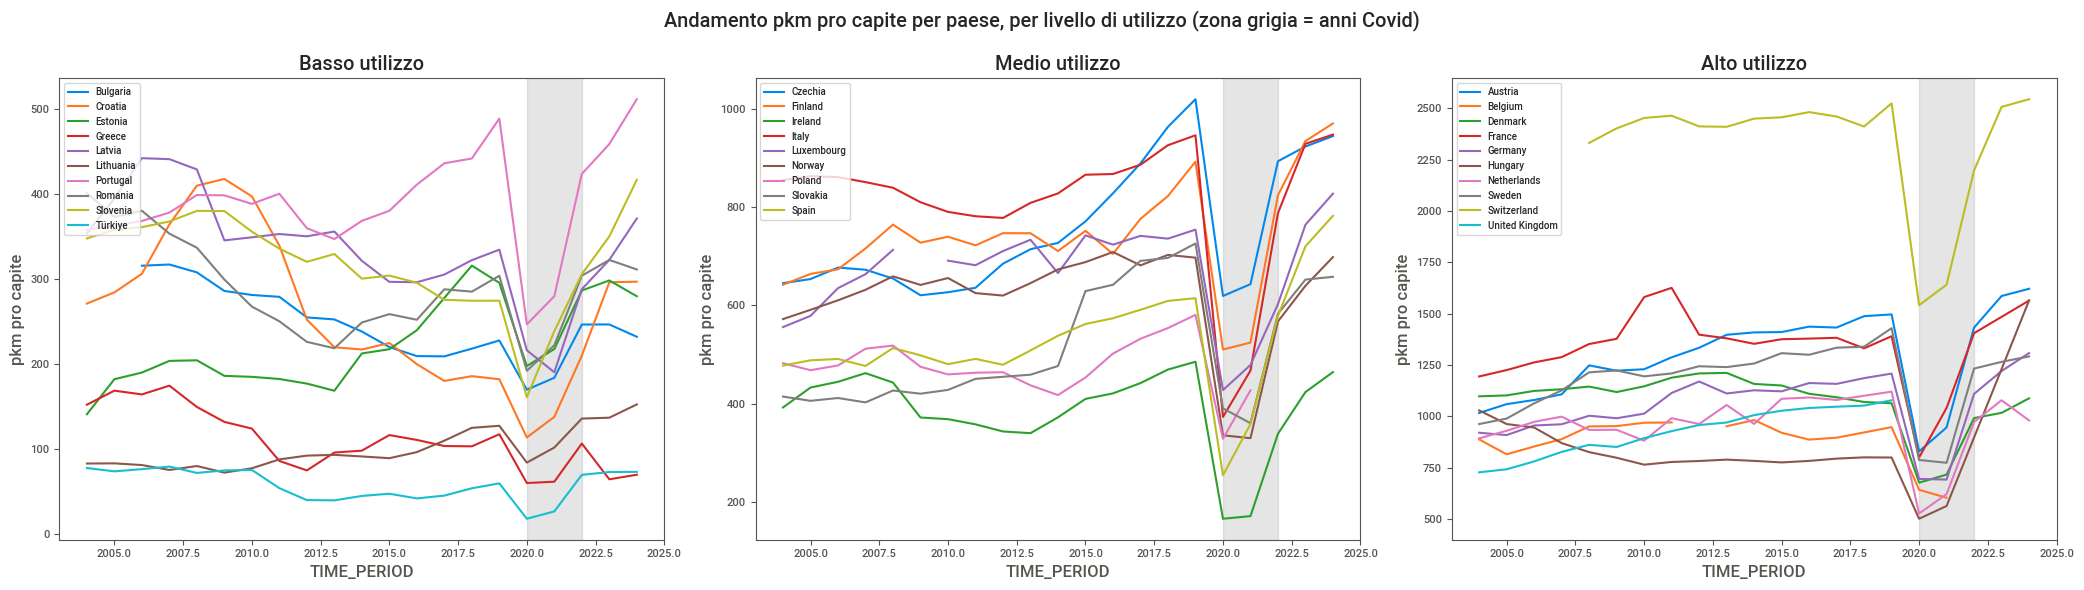

In [19]:
pre_covid_avg = (
    df[~df["TIME_PERIOD"].isin(EXCLUDE_YEARS)]
    .groupby("geo")["passengers_per_capita"].mean()
)
tiers = pd.qcut(pre_covid_avg, 3, labels=["Basso utilizzo", "Medio utilizzo", "Alto utilizzo"])
pivot = df.pivot(index="TIME_PERIOD", columns="geo", values="passengers_per_capita")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, tier_name in zip(axes, ["Basso utilizzo", "Medio utilizzo", "Alto utilizzo"]):
    tier_countries = tiers[tiers == tier_name].index
    pivot[tier_countries].plot(ax=ax, legend=True, fontsize=8)
    ax.axvspan(min(EXCLUDE_YEARS), max(EXCLUDE_YEARS), color="grey", alpha=0.2)
    ax.set_title(tier_name)
    ax.set_ylabel("pkm pro capite")
    ax.legend(fontsize=7, loc="upper left")
fig.suptitle("Andamento pkm pro capite per paese, per livello di utilizzo (zona grigia = anni Covid)")
plt.tight_layout()
plt.show()

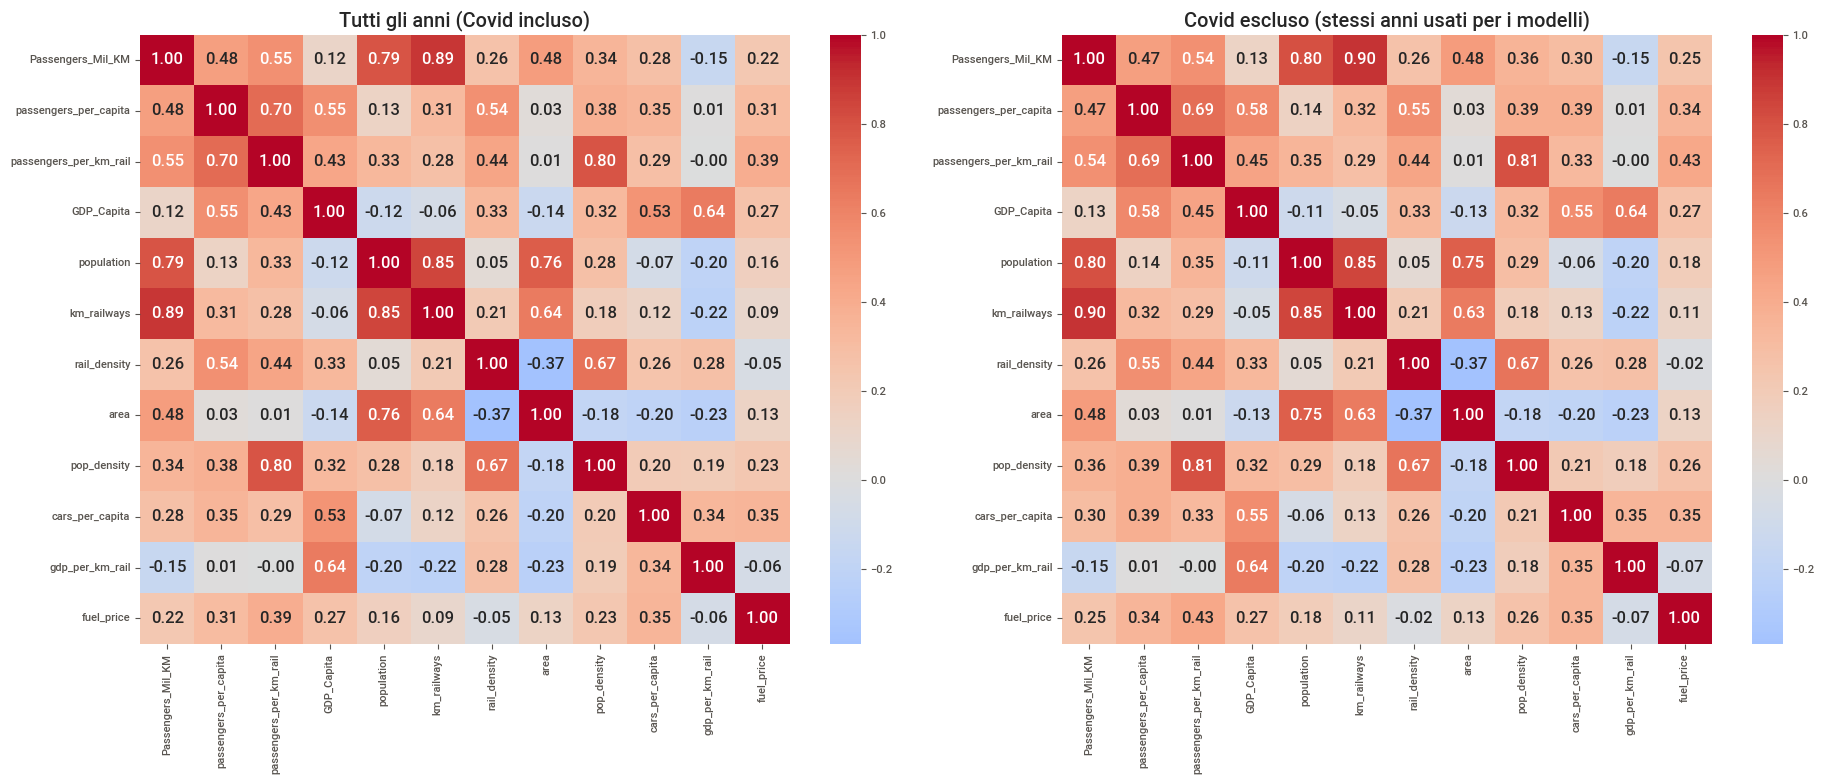

In [20]:
features_corr = ["Passengers_Mil_KM", "passengers_per_capita", "passengers_per_km_rail",
                  "GDP_Capita", "population", "km_railways", "rail_density",
                  "area", "pop_density", "cars_per_capita", "gdp_per_km_rail", "fuel_price"]
corr_all_years = df[features_corr].corr()
corr_no_covid = df[~df["TIME_PERIOD"].isin(EXCLUDE_YEARS)][features_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(19, 8))
sns.heatmap(corr_all_years, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title("Tutti gli anni (Covid incluso)")
sns.heatmap(corr_no_covid, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Covid escluso (stessi anni usati per i modelli)")
plt.tight_layout()
plt.show()

**Perche' `gdp_per_km_rail` e' negativamente correlato con entrambi i target, nonostante sia
costruito a partire dal PIL (una relazione positiva sarebbe l'intuizione naturale)?**
`gdp_per_km_rail = GDP_Capita / km_railways`. Il problema e' che tra i paesi europei `km_railways`
(valore assoluto) varia molto di piu' del `GDP_Capita` — da poche centinaia di km per un paese
piccolo a decine di migliaia per Germania o Francia, un fattore anche 50-100x, contro un fattore
3-5x per il PIL pro capite tra il paese piu' ricco e il piu' povero. Di conseguenza il rapporto e'
dominato dal denominatore: si comporta piu' come un (inverso) indicatore di estensione della rete
che come un indicatore di ricchezza. Un paese con una rete estesa ha automaticamente
`gdp_per_km_rail` basso — indipendentemente da quanto sia ricco — e una rete piu' estesa tende
anche ad avere piu' passeggeri (piu' stazioni, piu' servizio, `rail_density` piu' alta). Il risultato
e' che `gdp_per_km_rail` finisce negativamente correlato con l'uso del treno, pur chiamandosi
"gdp". E' lo stesso fenomeno di correlazione spuria tra rapporti segnalato piu' sotto (sezione 8):
qui `GDP_Capita` e `rail_density` sono gia' presenti separatamente tra le feature, quindi
`gdp_per_km_rail` viene escluso dal modello — resta qui solo a scopo illustrativo, come esempio
concreto di come un rapporto possa essere dominato dal denominatore invece che dal numeratore.

## 8. Modelli predittivi: pkm pro capite e pkm per km di rete

**Correzione 1 (target leakage):** il modello originale prediceva `Passengers_Mil_KM` (valore
assoluto) usando tra le feature `passengers_per_capita`, che e' una trasformazione diretta del
target stesso (R² artificialmente vicino a 1). Qui si predicono i due target normalizzati discussi
in precedenza — pkm pro capite e pkm per km di rete.

**Correzione 2 (variabili di scala non normalizzate):** `population`, `area` e `km_railways` in
valore assoluto non sono predittori sensati per un target gia' normalizzato — dicono solo "quanto e'
grande il paese", non "quanto e' usato il treno", e sono ridondanti con le densita' gia' incluse
(`km_railways = rail_density * area`, quindi tenere tutte e tre crea collinearita' inutile).

**Correzione 3 (`gdp_per_km_rail` escluso):** come illustrato in sezione 7, questo rapporto e' in
pratica dominato da `km_railways` (che varia 50-100x tra paesi) molto piu' che da `GDP_Capita` (che
varia 3-5x), quindi si comporta da proxy invertita dell'estensione della rete invece che da
indicatore di ricchezza — e i suoi due componenti (`GDP_Capita`, `rail_density`) sono gia' presenti
separatamente tra le feature.

Restano quindi solo variabili di intensita'/tasso genuinamente indipendenti: `GDP_Capita`,
`rail_density`, `pop_density`, `cars_per_capita`, `fuel_price`.

*Limite residuo, da tenere presente:* alcune di queste feature condividono comunque una componente
con il denominatore del target (es. `cars_per_capita` e `passengers_per_capita` sono entrambe divise
per `population`; `rail_density` condivide `km_railways` con `passengers_per_km_rail`). Questo puo'
generare una correlazione "spuria" tra rapporti che condividono lo stesso denominatore (fenomeno
noto in statistica, risalente a Pearson 1897), non del tutto eliminabile se si vogliono confronti
normalizzati tra paesi di dimensioni diverse. Un modello a effetti fissi o in log-log (sezione 11)
sarebbe un modo piu' rigoroso per verificare la robustezza di queste relazioni.

In [21]:
FEATURES = ["GDP_Capita", "rail_density", "pop_density", "cars_per_capita", "fuel_price"]
TARGETS = ["passengers_per_capita", "passengers_per_km_rail"]

# Solo qui si escludono gli anni Covid (EXCLUDE_YEARS): il resto del notebook li mostra.
df_model = (
    df[~df["TIME_PERIOD"].isin(EXCLUDE_YEARS)]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=FEATURES + TARGETS)
)
print(f"Righe disponibili per il modello (Covid escluso): {len(df_model)}")

results = {}
for target in TARGETS:
    X, y = df_model[FEATURES], df_model[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    linear = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]).fit(X_train, y_train)
    forest = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)

    results[target] = {"X_test": X_test, "y_test": y_test, "linear": linear, "forest": forest}

    print(f"\n=== {target} ===")
    for name, model in [("Linear Regression", linear), ("Random Forest", forest)]:
        pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)
        print(f"{name:18s} MAE={mae:12.2f}  RMSE={rmse:12.2f}  R2={r2:.3f}")

Righe disponibili per il modello (Covid escluso): 414

=== passengers_per_capita ===
Linear Regression  MAE=      226.24  RMSE=      296.32  R2=0.366
Random Forest      MAE=       37.09  RMSE=       55.95  R2=0.977

=== passengers_per_km_rail ===
Linear Regression  MAE=   513045.12  RMSE=   663929.97  R2=0.774
Random Forest      MAE=   113566.06  RMSE=   233993.62  R2=0.972


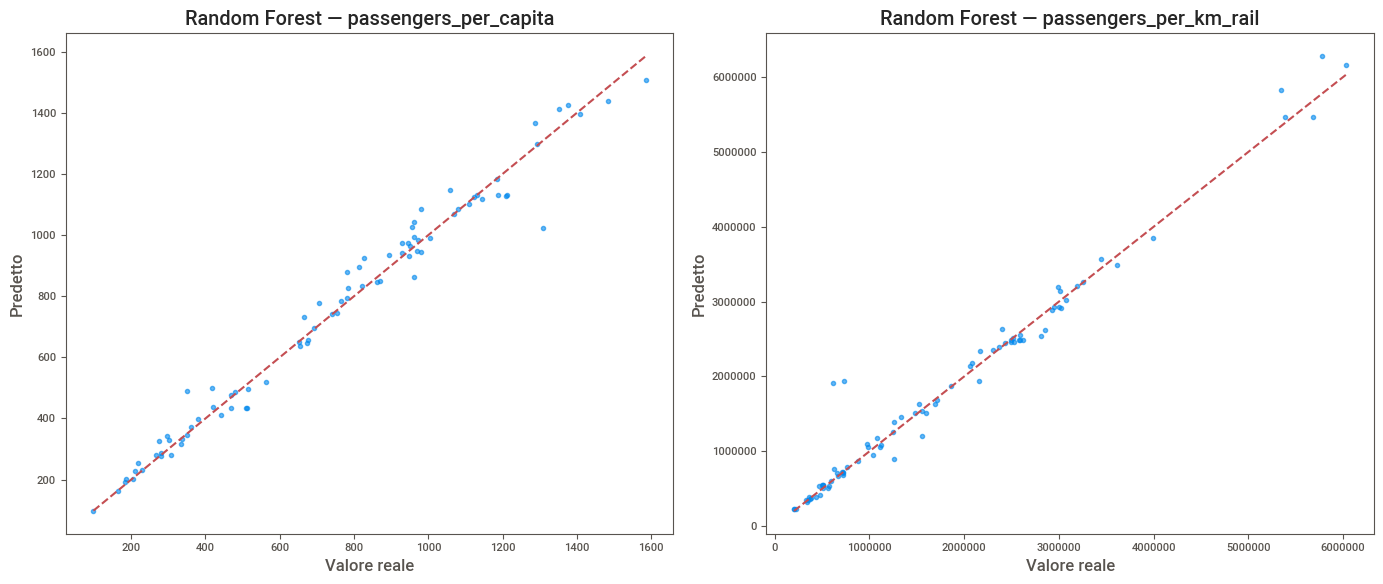

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, target in zip(axes, TARGETS):
    y_test = results[target]["y_test"]
    pred = results[target]["forest"].predict(results[target]["X_test"])
    ax.scatter(y_test, pred, alpha=0.6)
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, "r--")
    ax.set_xlabel("Valore reale")
    ax.set_ylabel("Predetto")
    ax.set_title(f"Random Forest — {target}")
plt.tight_layout()
plt.show()

**Importanza vs. direzione dell'effetto.** L'importanza del Random Forest misura quanto una
feature contribuisce alla previsione, ma non dice se l'effetto e' positivo o negativo. Per il segno
si usano i coefficienti standardizzati della regressione lineare (feature scalate con
`StandardScaler`, quindi i coefficienti sono direttamente confrontabili tra loro): coefficiente
positivo = la feature aumenta il target, negativo = lo riduce.

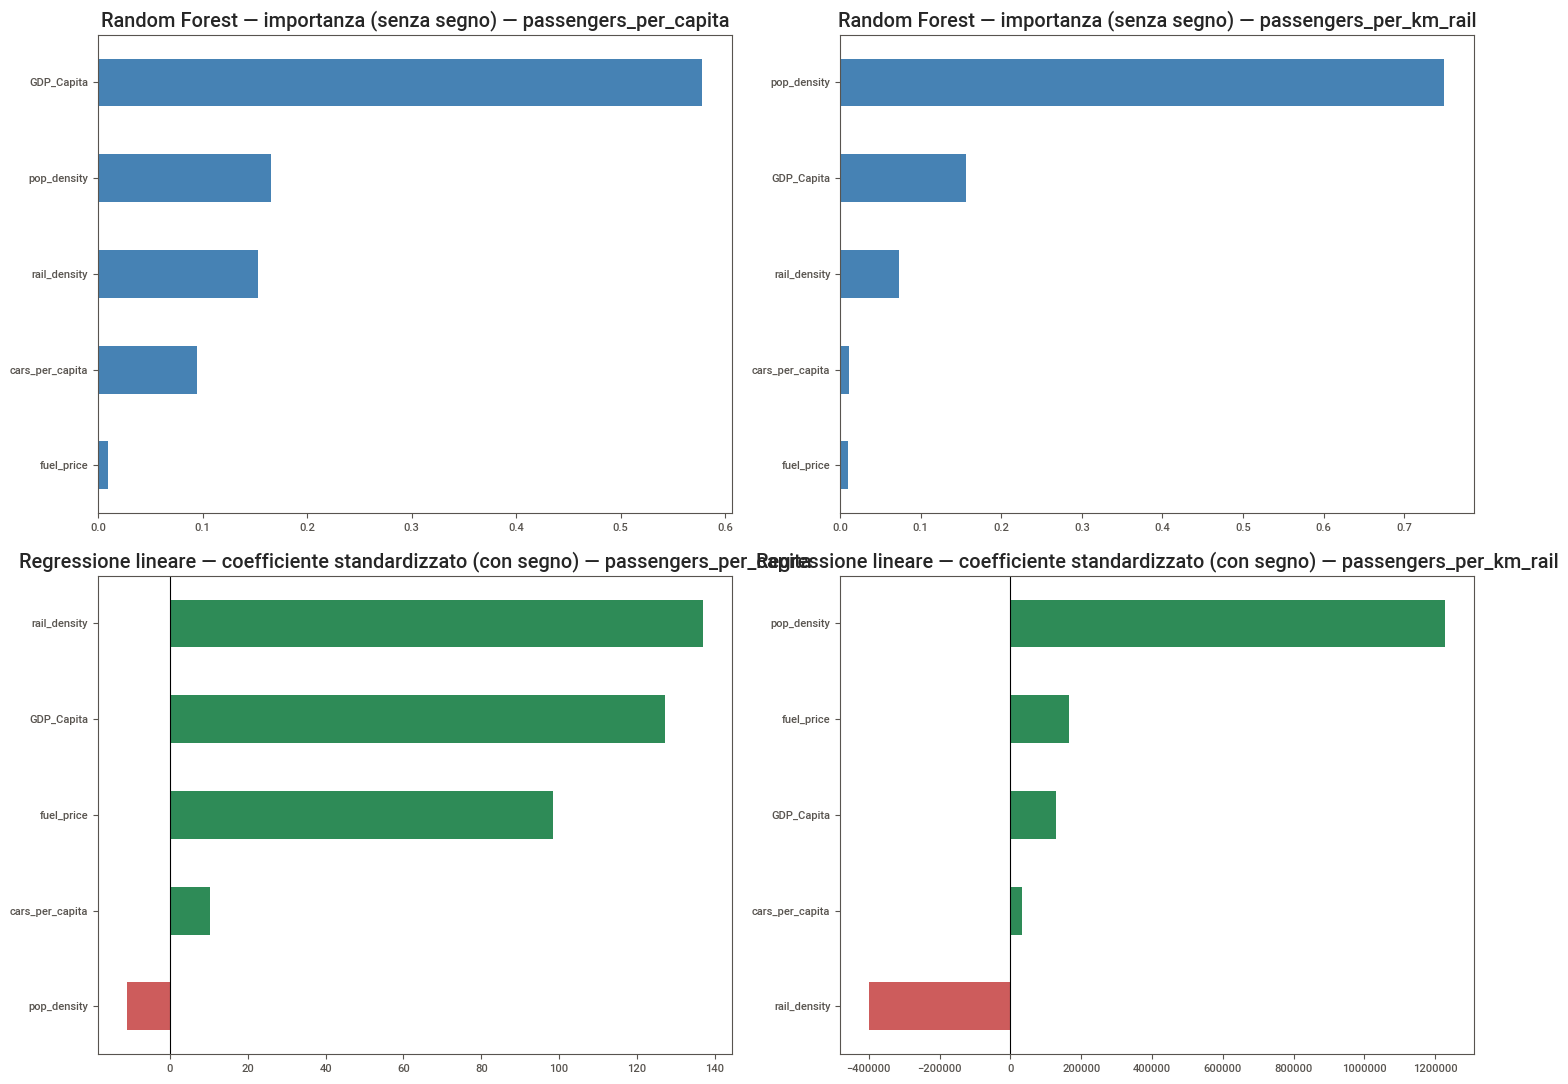

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for col, target in enumerate(TARGETS):
    forest_imp = pd.Series(results[target]["forest"].feature_importances_, index=FEATURES).sort_values()
    forest_imp.plot(kind="barh", ax=axes[0, col], color="steelblue")
    axes[0, col].set_title(f"Random Forest — importanza (senza segno) — {target}")

    coef = results[target]["linear"].named_steps["model"].coef_
    lin_coef = pd.Series(coef, index=FEATURES).sort_values()
    colors = ["indianred" if v < 0 else "seagreen" for v in lin_coef]
    lin_coef.plot(kind="barh", ax=axes[1, col], color=colors)
    axes[1, col].axvline(0, color="black", linewidth=0.8)
    axes[1, col].set_title(f"Regressione lineare — coefficiente standardizzato (con segno) — {target}")
plt.tight_layout()
plt.show()

## 9. Profilo e clustering dei paesi

Si aggregano gli anni 2013-2018 (finestra pre-Covid, piu' stabile) per paese e si raggruppano i
paesi in cluster in base a utilizzo del treno, densita' della rete, ricchezza, densita' abitativa e
motorizzazione.

In [24]:
PROFILE_YEARS = range(2013, 2019)
profile = df[df["TIME_PERIOD"].isin(PROFILE_YEARS)].groupby("geo").agg(
    passengers_per_capita=("passengers_per_capita", "mean"),
    rail_density=("rail_density", "mean"),
    GDP_Capita=("GDP_Capita", "mean"),
    population=("population", "mean"),
    area=("area", "mean"),
    cars_per_capita=("cars_per_capita", "mean"),
).reset_index()
profile["pop_density"] = profile["population"] / profile["area"]
profile = profile.dropna()

CLUSTER_FEATURES = ["passengers_per_capita", "rail_density", "GDP_Capita", "pop_density", "cars_per_capita"]
X_scaled = StandardScaler().fit_transform(profile[CLUSTER_FEATURES])

print("=== Scelta di k (elbow + silhouette) ===")
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    print(f"k={k}: inertia={km.inertia_:.1f}  silhouette={silhouette_score(X_scaled, km.labels_):.3f}")

=== Scelta di k (elbow + silhouette) ===
k=2: inertia=85.5  silhouette=0.348
k=3: inertia=67.0  silhouette=0.288
k=4: inertia=55.0  silhouette=0.298
k=5: inertia=48.5  silhouette=0.236
k=6: inertia=38.8  silhouette=0.245
k=7: inertia=29.9  silhouette=0.260
k=8: inertia=25.7  silhouette=0.252


In [25]:
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_scaled)
profile["cluster"] = km.labels_

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(coords, columns=["Pc1", "Pc2"])
df_pca["cluster"] = pd.Categorical(km.labels_, categories=sorted(set(km.labels_)), ordered=True)
df_pca["geo"] = profile["geo"].values

fig = px.scatter(df_pca, x="Pc1", y="Pc2", color="cluster", hover_name="geo",
                  title="Cluster di paesi — proiezione PCA (2 componenti)")
fig.show()

profile[["geo", "cluster"]].sort_values("cluster").reset_index(drop=True)

,geo,cluster
0,Croatia,0
1,Bulgaria,0
2,Estonia,0
3,Hungary,0
4,Lithuania,0
5,Latvia,0
6,Greece,0
7,Poland,0
8,Portugal,0
9,Türkiye,0


**Lettura dei cluster (tipica, i numeri esatti dei cluster possono variare a seconda della
run):**

- **Basso utilizzo** — perlopiu' Europa dell'Est e periferia mediterranea: PIL piu' basso, rete
  ferroviaria meno densa.
- **Medio utilizzo** — grandi economie dell'Europa occidentale/centrale con reti sviluppate ma alta
  densita' di auto.
- **Alto utilizzo** — Nord Europa, Francia, Austria: PIL pro capite alto, forte cultura del trasporto
  pubblico.
- **Paesi piccoli, densi e ricchi** (es. Svizzera, Lussemburgo) — utilizzo pro capite fuori scala:
  il treno e' piu' efficiente dell'auto per spostamenti brevi tra citta' vicine.

`cars_per_capita` correla positivamente (non negativamente) con `passengers_per_capita`: non e' che
piu' auto significhi meno treno, ma che entrambi riflettono un livello generale di mobilita' piu'
alto nei paesi ricchi (variabile confondente: `GDP_Capita`).

## 10. Salvataggio dataset finale

In [26]:
assert np.isinf(df.select_dtypes(include=[np.number])).sum().sum() == 0, "Valori infiniti residui"
df.to_csv("df_final.csv", index=False)
print(f"Shape finale: {df.shape}")
df.head()

Shape finale: (590, 14)


,geo,TIME_PERIOD,Passengers_Mil_KM,km_railways,population,GDP_Capita,area,cars_per_capita,fuel_price,passengers_per_capita,passengers_per_km_rail,rail_density,pop_density,gdp_per_km_rail
0,Austria,2004,8274.0,5675.0,8142573.0,39620.0,83879.0,501.0,NaN,1016.140721,1.457974e+06,0.067657,97.075227,6.981498
1,Austria,2005,8685.0,5691.0,8201359.0,40270.0,83879.0,504.0,1.033531,1058.970836,1.526094e+06,0.067848,97.776070,7.076085
2,Austria,2006,8907.0,5702.0,8254298.0,41370.0,83879.0,508.0,1.091796,1079.074199,1.562083e+06,0.067979,98.407206,7.255349
3,Austria,2007,9167.0,5702.0,8282984.0,42790.0,83879.0,511.0,1.121245,1106.726755,1.607682e+06,0.067979,98.749198,7.504384
4,Austria,2008,10365.0,5693.0,8307989.0,43270.0,83879.0,514.0,1.215694,1247.594334,1.820657e+06,0.067872,99.047306,7.600562


## 11. Sviluppi futuri e possibili estensioni

Analisi che si potrebbero aggiungere con dati esterni:

- **Modal split** — confrontare pkm treno con auto, aereo e bus (Eurostat `tran_hv_psmod`) per capire
  se un paese con basso uso del treno compensa con altre modalita' o si muove semplicemente meno.
- **Emissioni CO2 per passeggero-km** per modalita' (dati EEA/UIC) — lega l'uso del treno a un
  indicatore di sostenibilita', non solo di volume.
- **Prezzo del biglietto ferroviario/abbonamenti**, non solo del carburante — il prezzo relativo
  treno vs auto e' probabilmente piu' predittivo del solo prezzo carburante.
- **Elettrificazione della rete** (% km elettrificati, Eurostat `rail_if_line_atype`) e **velocita'
  media/quota alta velocita'** come proxy di qualita' del servizio, non solo di estensione.
- **Grado di urbanizzazione** (Eurostat `urb_*` o quota popolazione urbana) come determinante di
  domanda, complementare a `pop_density`.
- **Investimenti infrastrutturali** (spesa pubblica in trasporto, fondi TEN-T) per collegare
  `passengers_per_km_rail` a policy/investimento invece che solo a variabili strutturali.
- **Modello a effetti fissi (panel data)** — con piu' anni per paese, un modello a effetti fissi
  paese/anno isolerebbe meglio l'effetto delle variabili che cambiano nel tempo, invece della
  regressione pooled usata qui.
- **Serie storiche per paese** (ARIMA/Prophet) per previsioni invece di un confronto cross-country.
- **Diff-in-diff su eventi specifici** (es. apertura di nuove linee ad alta velocita') per stimare
  l'impatto causale su `passengers_per_km_rail`, invece della sola correlazione.
- **Survey Eurobarometro sulla mobilita'** per capire le determinanti soggettive (percezione,
  comodita', abitudine) che i dati strutturali da soli non colgono.